In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import base64
from datetime import date, datetime
import json
import os
import random
import re
import time

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import seaborn as sns
plt.rcParams['axes.unicode_minus'] = False
# Jupyter Notebook
%matplotlib inline
%config InlineBackend.figure_format='retina'

from IPython.display import display
from tqdm import tqdm

# Set random seed for reproducibility
def set_seeds(seed=777):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

SEED = 777
set_seeds(SEED)
print(f'Random seed set to: {SEED}')
# Checking
print(np.random.rand(3))
set_seeds(SEED)
print(np.random.rand(3))

# Display entire DataFrame
def print_all(df):
    with pd.option_context('display.max_rows', None, 
                           'display.max_columns', None, 
                           'display.float_format', '{:,.4f}'.format):
        display(df)
# Display entire columns
def print_cols(df, n=5): 
    with pd.option_context('display.max_columns', None,
                          'display.float_format', '{:,.4f}'.format):
        print(df.shape)
        display(df[:n])

Random seed set to: 777
[0.15266373 0.30235661 0.06203641]
[0.15266373 0.30235661 0.06203641]


In [3]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, log_loss

from models_logreg import fit_logreg, predict_label, predict_prob, add_intercept, fit_logreg_no_intercept_penalty

In [4]:
# ===================================================================
# Configurations

# Path
# Get the path of the current script file
CURRENT_DIR = os.getcwd()

# Move up one level to the parent directory
PARENT_DIR = os.path.dirname(os.getcwd())

# Path to data directory
DATA_ROOT = os.path.join(CURRENT_DIR, 'data')

# Path to dataset files
TRAIN_DATA_PATH = os.path.join(DATA_ROOT, 'train_scaled.csv')
TEST_DATA_PATH = os.path.join(DATA_ROOT, 'test_scaled.csv')

In [5]:
# MSU colors (Spartan Green + White)
# msu_colors = ['#D3D3D3', '#18453B'] # Primary: #18453B(Spartan Green), Secondary: #909090(Warm Gray), #D7D2CB(Clay), #D3D3D3(Light Gray)
# sns.set_palette(sns.color_palette(msu_colors))
# plt.rcParams['figure.facecolor'] = 'white' # white as background

# Data Load

In [6]:
# Target column
target_col = 'def_pay'

# Load dataset
train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

train_df[target_col] = train_df[target_col].astype('category')
test_df[target_col] = test_df[target_col].astype('category')

print_cols(train_df, 2)
print_cols(test_df, 2)

(24000, 27)


,limit_bal,sex_female,age,pay_1,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,edu_1,edu_2,edu_3,marr_1,marr_2,def_pay
0,-0.6761,1,-1.1345,-0.4695,-0.4000,-0.3889,-0.3446,-0.3127,-0.3195,-0.0815,-0.0624,-0.0387,0.0062,0.0393,0.0865,-0.2138,-0.1676,-0.1818,-0.2166,-0.0966,-0.2932,0,1,0,0,1,0
1,0.9401,1,1.4672,-0.4695,-0.4000,-0.3889,-0.3446,-0.3127,-0.3195,0.0198,0.0663,0.0990,0.1729,0.2424,0.2854,-0.1873,-0.1752,-0.1831,-0.1844,-0.1866,-0.1795,0,1,0,0,0,0


(6000, 27)


,limit_bal,sex_female,age,pay_1,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,edu_1,edu_2,edu_3,marr_1,marr_2,def_pay
0,-0.1374,1,-0.9177,-0.4695,-0.4000,-0.3889,-0.3446,-0.3127,-0.3195,-0.6753,-0.6666,-0.5963,-0.6015,0.4911,0.4874,-0.2319,-0.0118,-0.0353,4.3094,-0.1187,-0.1250,0,1,0,0,1,0
1,0.2474,0,-0.3757,2.1586,-0.4000,-0.3889,-0.3446,-0.3127,-0.3195,1.4848,1.6005,0.5041,-0.6737,-0.6642,-0.6534,0.1158,-0.0854,-0.2882,-0.3152,-0.3228,-0.2932,0,1,0,0,1,1


In [7]:
# Split target(y), features(X), train, test datasets

X_train = train_df.drop(target_col, axis=1)
y_train = train_df[target_col]

X_test = test_df.drop(target_col, axis=1)
y_test = test_df[target_col]

# Set y data type as int
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Run Experiments for L2 Logistic Regression

In [8]:
# Run Optimizers

# Settings
lam = 1.0 # L2 regularization strength
tol = 1e-6 # Convergence tolerance
max_iter = 5000 # Max iterations

# List to store results for DataFrame
records = [] # To store summary metrics
results = {} # To store raw data for plotting
optimizers = ['gd', 'gd_armijo', 'cg', 'bfgs']
names = ['Gradient Descent (Fixed)', 'GD + Armijo', 'NLCG (PR+)', 'BFGS']

for opt_name, disp_name in zip(optimizers, names):
    start_t = time.time()
    
    # 1. Train model
    w_opt, info = fit_logreg(X_train, y_train, lam=lam, optimizer=opt_name, 
                             step=1e-1, # step size for fixed GD; 1e-2, 1e-3 --> more iterations
                             alpha0=1.0, # standard start for other models
                             tol=tol, 
                             max_iter=max_iter)
    
    end_t = time.time()
    elapsed = end_t - start_t
    
    # 2. Predict and evaluate on test set (probabilities and hard labels)
    # Add intercept column for prediction functions
    X_test_b = add_intercept(X_test)
    X_train_b = add_intercept(X_train)
    # Generate predictions
    # - get probabilities (for Log-Loss, ROC-AUC, PR-AUC)
    y_prob_train = predict_prob(w_opt, X_train_b)
    y_prob_test = predict_prob(w_opt, X_test_b)
    # - get hard labels (0 or 1) (for Accuracy, F1)
    y_pred_train = predict_label(w_opt, X_train_b)
    y_pred_test = predict_label(w_opt, X_test_b)
    
    # 3. Calculate metrics
    # Basic info
    final_loss = info['history'][-1][1]
    final_gnorm = info['history'][-1][2] # Gradient Norm
    iters = info['iters']
    
    # Classification metrics (test set)
    acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    ll = log_loss(y_test, y_prob_test)
    roc = roc_auc_score(y_test, y_prob_test)
    pr = average_precision_score(y_test, y_prob_test)
    
    # 4. Save results
    # for plotting
    results[opt_name] = {
        'w': w_opt,
        'info': info,
        'name': disp_name,
        'time': elapsed
    }
    
    # for table
    records.append({
        'Algorithm': disp_name,
        'Iters': iters,
        'Time(s)': elapsed,
        'Final Loss': final_loss,
        'Grad Norm': final_gnorm,
        'Accuracy': acc,
        'F1 Score': f1,
        'Log-Loss': ll,
        'ROC-AUC': roc,
        'PR-AUC': pr
    })

# Resul table
df_results = pd.DataFrame(records)
format_dict = {
    'Time(s)': '{:.4f}', 'Final Loss': '{:.6f}', 'Grad Norm': '{:.2e}',
    'Accuracy': '{:.4f}', 'F1 Score': '{:.4f}', 'Log-Loss': '{:.4f}', 
    'ROC-AUC': '{:.4f}', 'PR-AUC': '{:.4f}'
}
display(df_results.style.format(format_dict))

,Algorithm,Iters,Time(s),Final Loss,Grad Norm,Accuracy,F1 Score,Log-Loss,ROC-AUC,PR-AUC
0,Gradient Descent (Fixed),93,0.0525,0.609918,9.40e-07,0.8057,0.3990,0.5600,0.7518,0.5019
1,GD + Armijo,13,0.0149,0.609918,9.51e-07,0.8057,0.3990,0.5600,0.7518,0.5019
2,NLCG (PR+),18,0.0186,0.609918,4.35e-07,0.8057,0.3990,0.5600,0.7518,0.5019
3,BFGS,10,0.0090,0.609918,1.45e-07,0.8057,0.3990,0.5600,0.7518,0.5019


- All optimization methods reach the same final loss and identical evaluation metrics, and they converge to the same solution
    - BFGS is the fastest, requiring the fewest iterations and lowest runtime
    - Armijo GD also converges quickly with far fewer iterations than fixed-step GD
    - Fixed-step GD is the slowest, taking the most iterations and time
- Differences in optimization methods for Logistic Regression affect convergence speed and computational cost, but they have almost no impact on evaluation metrics
    - the loss function of Logistic Regression is convex and has a single global minimum --> so the solution are the same --> nearly identical predictions
- When the tolerance value is reduced tol=1e-10, the previously fast-converging BFGS method becomes slower

# Convergence Curves

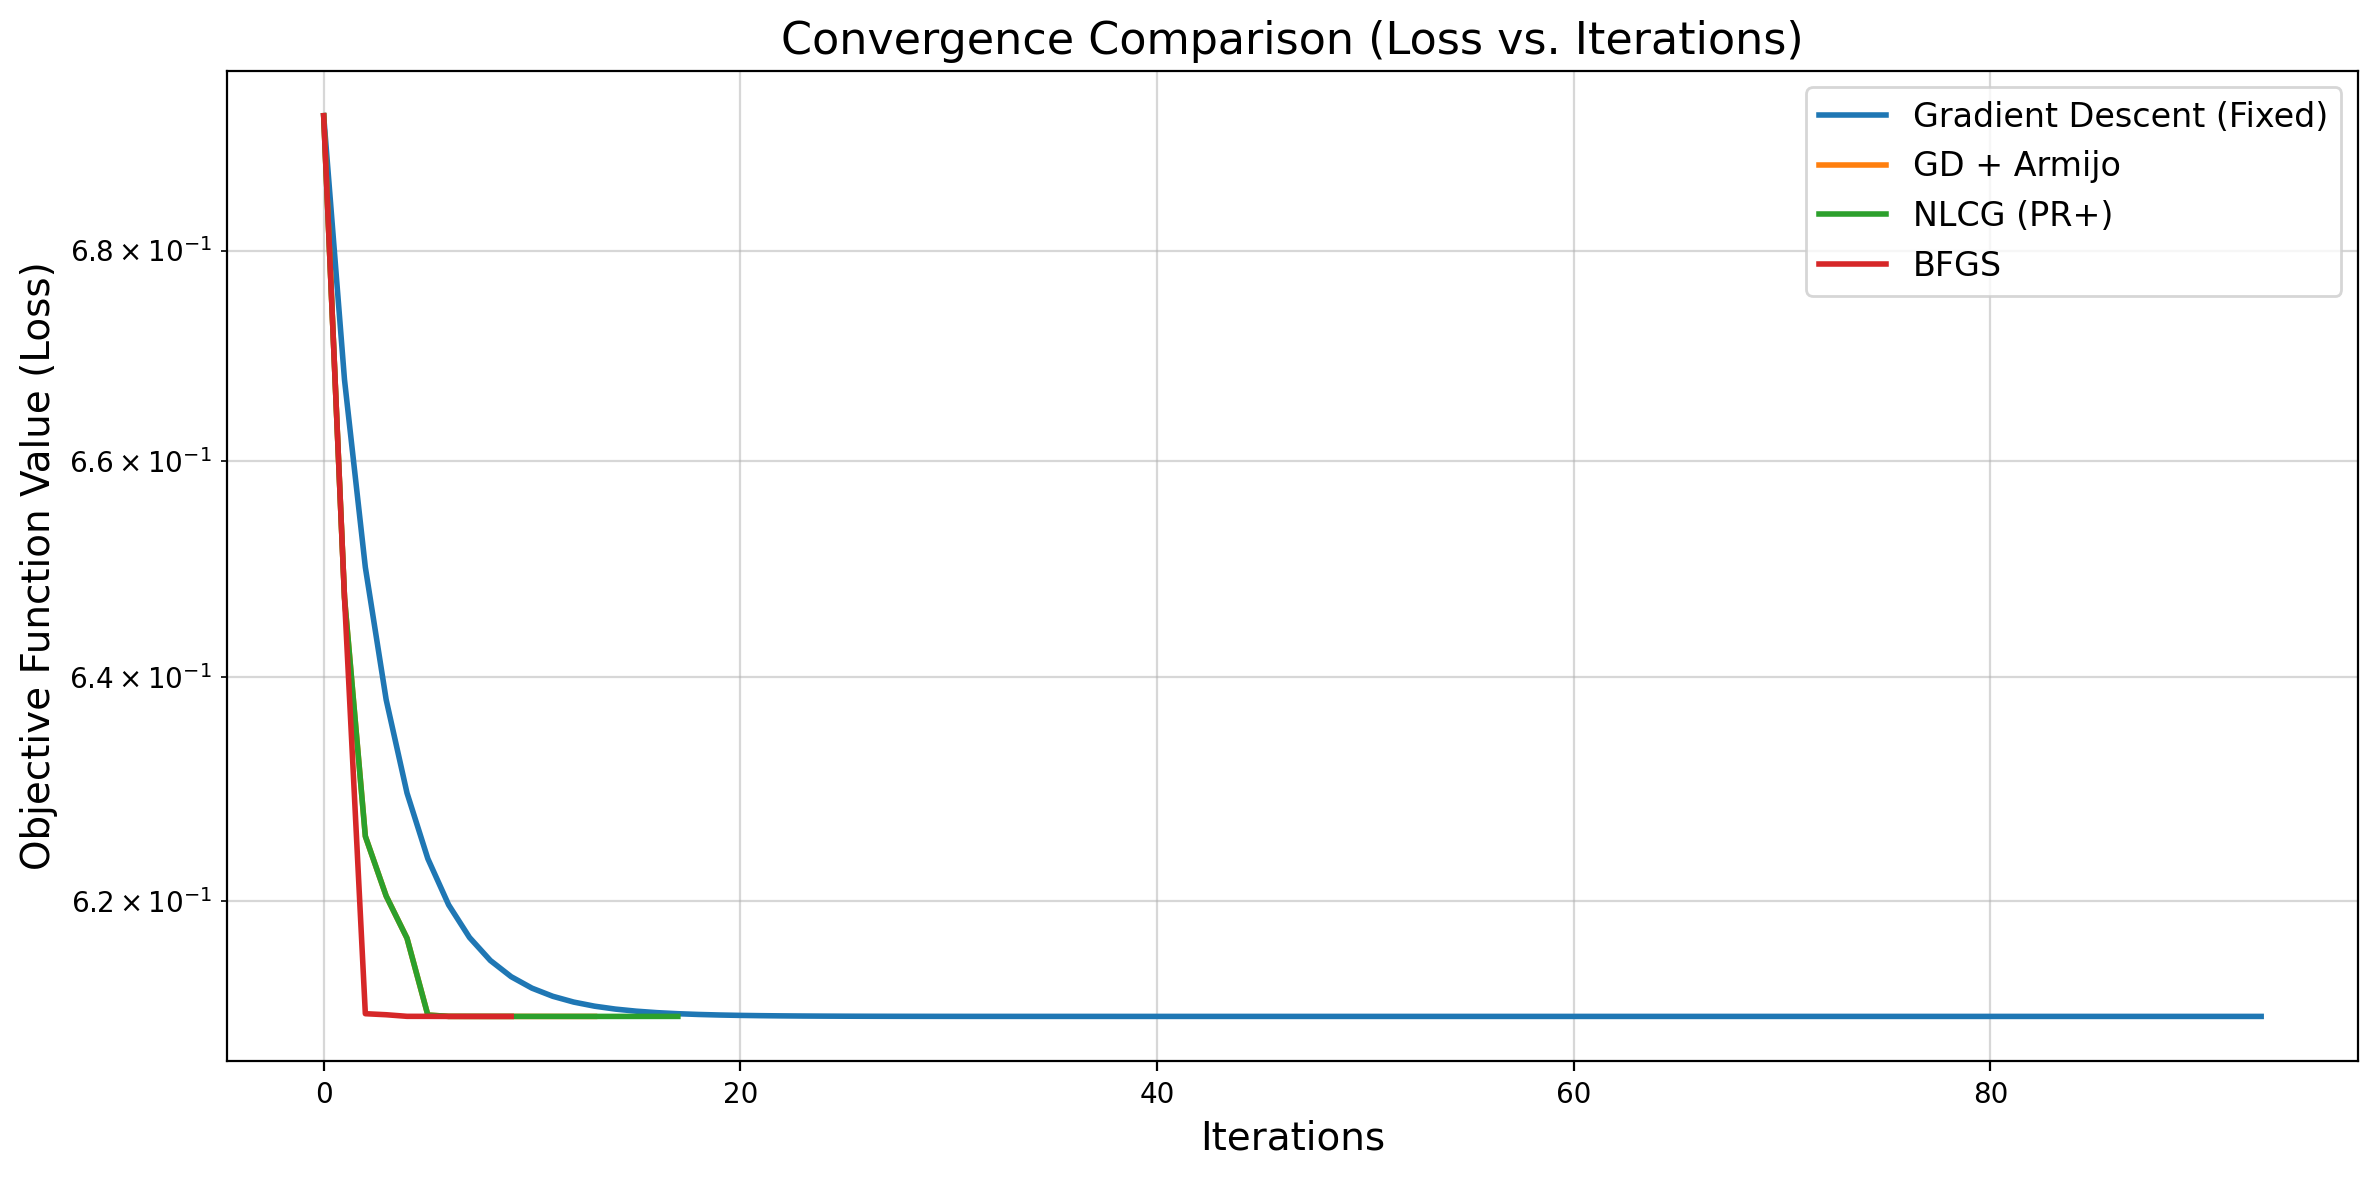

In [9]:
# Convergence curves

plt.figure(figsize=(12, 6))

for opt_name in optimizers:
    res = results[opt_name]
    hist = res['info']['history'] # list of (iter, loss, grad norm)
    
    # Extract iterations and loss values
    iters = [h[0] for h in hist]
    losses = [h[1] for h in hist]
    
    plt.plot(iters, losses, label=f'{res['name']}', linewidth=2)

plt.title(f'Convergence Comparison (Loss vs. Iterations)', fontsize=16)
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Objective Function Value (Loss)', fontsize=14)
plt.yscale('log') # Log scale
plt.grid(True, which='both', ls='-', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show();

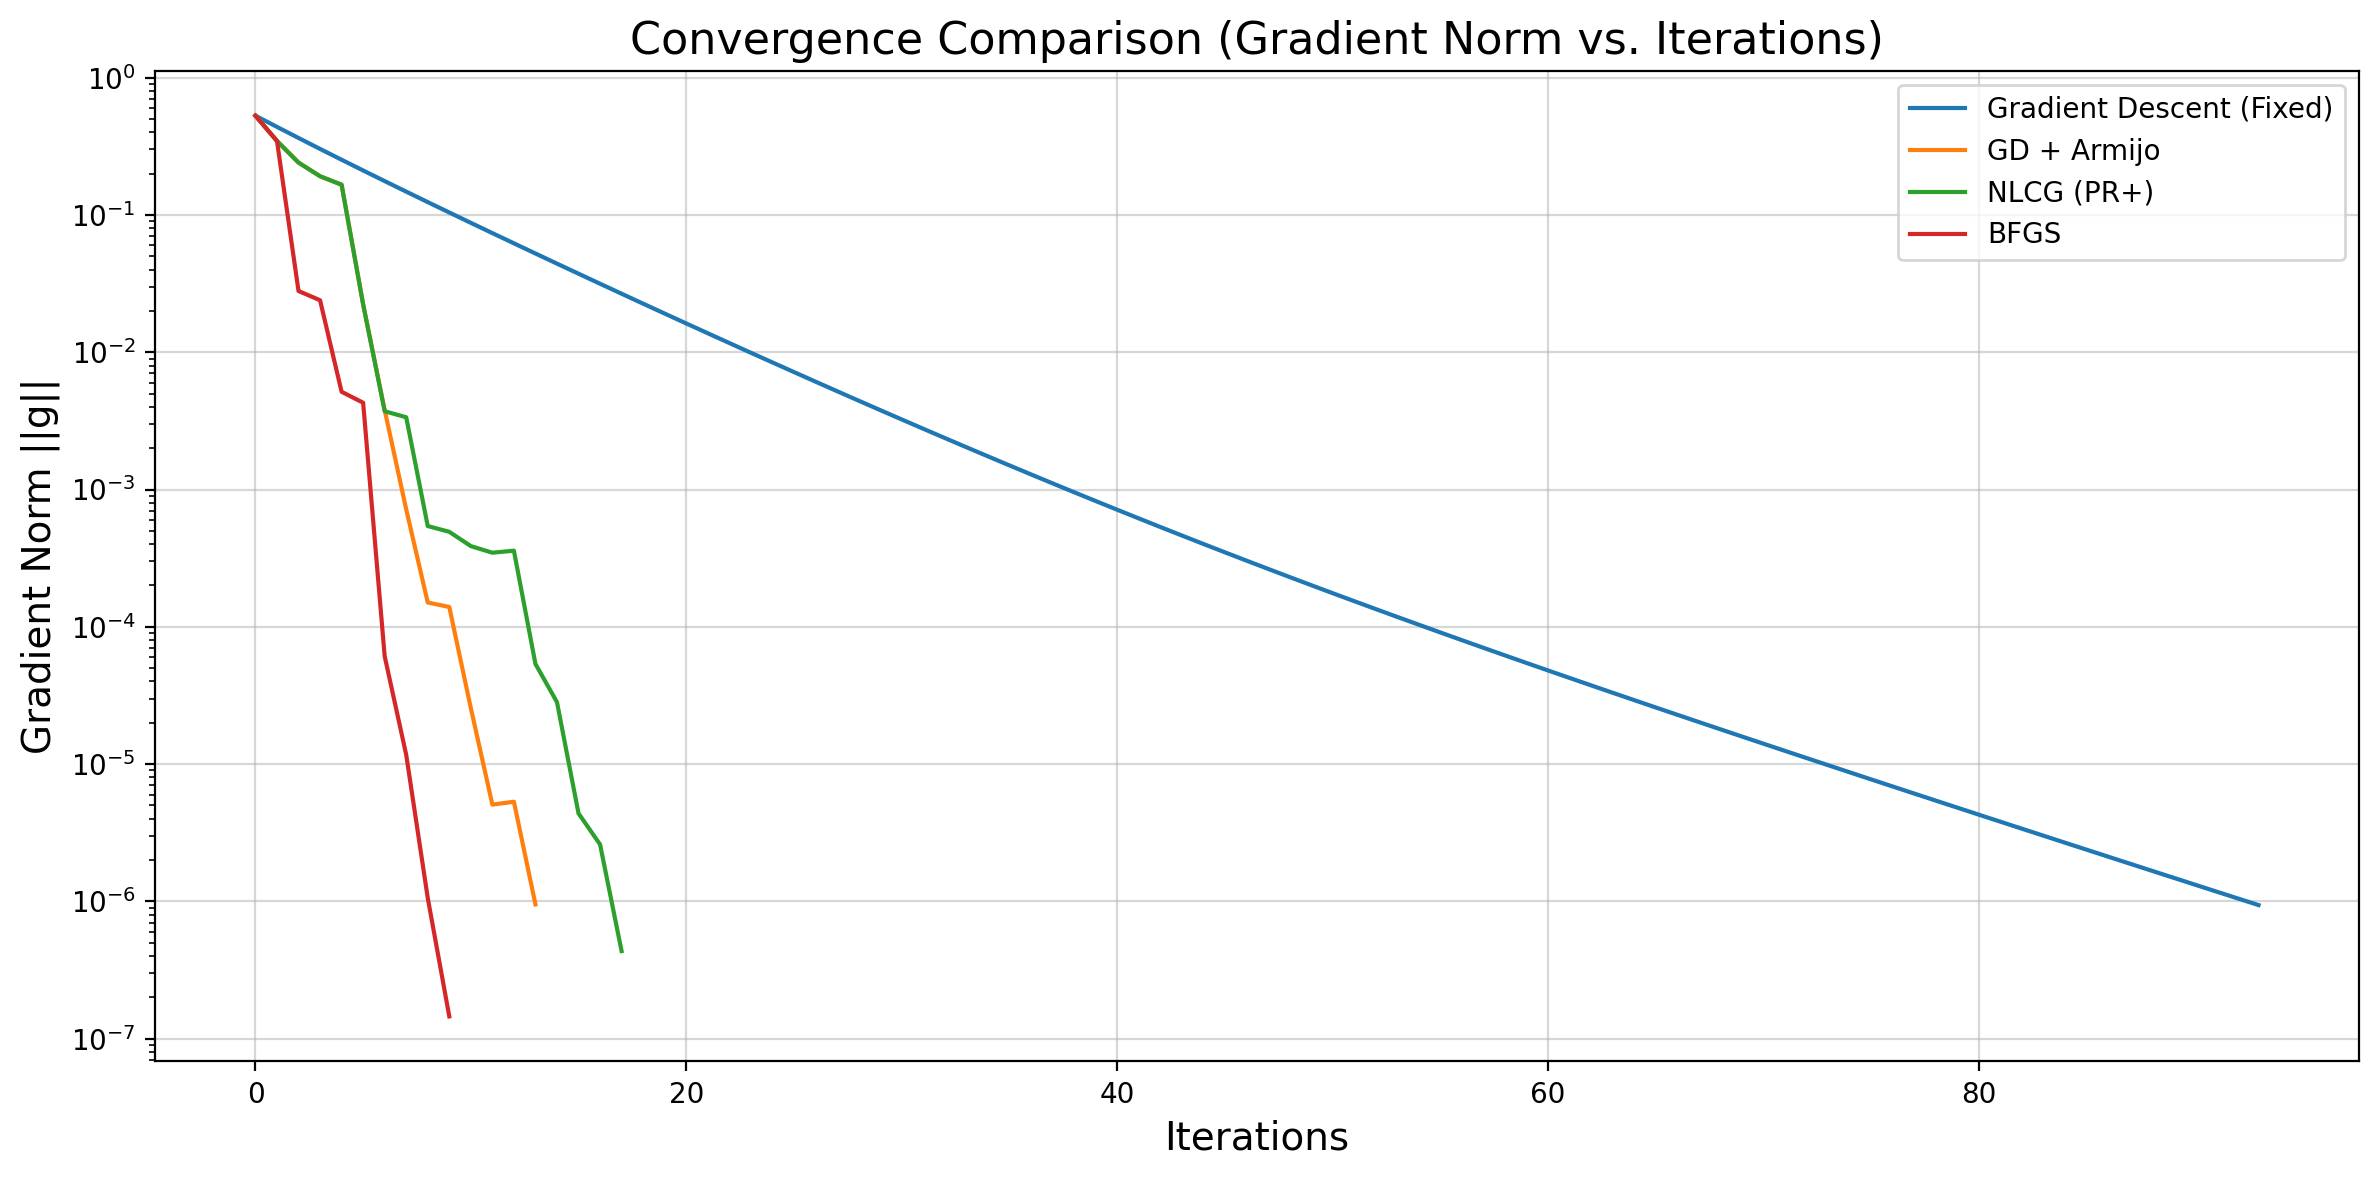

In [10]:
# Gradient Norm curves

plt.figure(figsize=(12, 6))

for opt_name in optimizers:
    res = results[opt_name]
    hist = res['info']['history'] # list of (iter, loss, grad norm)
    
    # Extract iterations and gradient norm
    iters = [h[0] for h in hist]
    gnorms = [h[2] for h in hist]
    
    plt.plot(iters, gnorms, label=res['name'])

plt.title(f'Convergence Comparison (Gradient Norm vs. Iterations)', fontsize=16)
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Gradient Norm ||g||', fontsize=14)
plt.yscale('log') # Log scale
plt.grid(True, ls='-', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show();

- Gradient norms consistently decrease across methods
- BFGS achieving the smallest gradient norm --> the most precise convergence

# Validation with Scikit-Learn

In [11]:
# Sklearn setting
# C = 1/lambda -- inverse regularization strength
C_val = 1.0 / lam # C = 1.0

# Sklearn Logistic Regression
# lbfgs solver -- standard for comparison with BFGS
clf = SklearnLogisticRegression(penalty='l2', tol=tol, C=C_val, fit_intercept=True, solver='lbfgs', max_iter=max_iter)
start_time = time.time()
clf.fit(X_train, y_train)
end_time = time.time()

# Predictions
y_prob_sk = clf.predict_proba(X_test)[:, 1] # Probability of class 1
y_pred_sk = clf.predict(X_test)

# Calculate Metrics
sk_metrics = {
    'Algorithm': 'Scikit-Learn (L-BFGS)',
    'Iters': clf.n_iter_[0],
    'Time(s)': end_time - start_time, # or 'N/A', 0.0
    'Final Loss': log_loss(y_train, clf.predict_proba(X_train)) + (0.5 * lam * np.sum(clf.coef_ ** 2)), # Approx objective
    'Grad Norm': 0.0, # 'N/A', 0.0
    'Accuracy': accuracy_score(y_test, y_pred_sk),
    'F1 Score': f1_score(y_test, y_pred_sk),
    'Log-Loss': log_loss(y_test, y_prob_sk),
    'ROC-AUC': roc_auc_score(y_test, y_prob_sk),
    'PR-AUC': average_precision_score(y_test, y_prob_sk)
}

# To dataframe
df_sk = pd.DataFrame([sk_metrics])
display(df_sk.style.format(format_dict))

,Algorithm,Iters,Time(s),Final Loss,Grad Norm,Accuracy,F1 Score,Log-Loss,ROC-AUC,PR-AUC
0,Scikit-Learn (L-BFGS),117,0.0659,2.252750,0.00e+00,0.8168,0.4447,0.4490,0.7572,0.5195


- sklearn's LR accuracy is slightly higher

## Discrepancy Analysis

In [12]:
# 1) In the reularization process in the L2-regualarized logistic regression function we made
# L2 penalty -> intercept(w[0]) excluded
# Gradient -> intercept no penalized

# 2) Change the regularization setting to match Scikit-learn's
# lambda = 1 / (n * C)
# C (used in our sklearn) = 1
# => lambda = 1 / 24000

# Settings
lam = 1/X_train.shape[0] # L2 regularization strength
tol = 1e-6 # Convergence tolerance
max_iter = 5000 # Max iterations

# List to store results for DataFrame
records = [] # To store summary metrics
results = {} # To store raw data for plotting
optimizers = ['gd', 'gd_armijo', 'cg', 'bfgs']
names = ['Gradient Descent (Fixed)', 'GD + Armijo', 'NLCG (PR+)', 'BFGS']

for opt_name, disp_name in zip(optimizers, names):
    start_t = time.time()
    
    # 1. Train model
    w_opt, info = fit_logreg_no_intercept_penalty(
        X_train, y_train, lam=lam, optimizer=opt_name, 
        step=1e-1, # step size for fixed GD; 1e-2, 1e-3 --> more iterations
        alpha0=1.0, # standard start for other models
        tol=tol, 
        max_iter=max_iter
    )
    
    end_t = time.time()
    elapsed = end_t - start_t
    
    # 2. Predict and evaluate on test set (probabilities and hard labels)
    # Add intercept column for prediction functions
    X_test_b = add_intercept(X_test)
    X_train_b = add_intercept(X_train)
    # Generate predictions
    # - get probabilities (for Log-Loss, ROC-AUC, PR-AUC)
    y_prob_train = predict_prob(w_opt, X_train_b)
    y_prob_test = predict_prob(w_opt, X_test_b)
    # - get hard labels (0 or 1) (for Accuracy, F1)
    y_pred_train = predict_label(w_opt, X_train_b)
    y_pred_test = predict_label(w_opt, X_test_b)
    
    # 3. Calculate metrics
    # Basic info
    final_loss = info['history'][-1][1]
    final_gnorm = info['history'][-1][2] # Gradient Norm
    iters = info['iters']
    
    # Classification metrics (test set)
    acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    ll = log_loss(y_test, y_prob_test)
    roc = roc_auc_score(y_test, y_prob_test)
    pr = average_precision_score(y_test, y_prob_test)
    
    # 4. Save results
    # for plotting
    results[opt_name] = {
        'w': w_opt,
        'info': info,
        'name': disp_name,
        'time': elapsed
    }
    
    # for table
    records.append({
        'Algorithm': disp_name,
        'Iters': iters,
        'Time(s)': elapsed,
        'Final Loss': final_loss,
        'Grad Norm': final_gnorm,
        'Accuracy': acc,
        'F1 Score': f1,
        'Log-Loss': ll,
        'ROC-AUC': roc,
        'PR-AUC': pr
    })

# Resul table
df_results = pd.DataFrame(records)
format_dict = {
    'Time(s)': '{:.4f}', 'Final Loss': '{:.6f}', 'Grad Norm': '{:.2e}',
    'Accuracy': '{:.4f}', 'F1 Score': '{:.4f}', 'Log-Loss': '{:.4f}', 
    'ROC-AUC': '{:.4f}', 'PR-AUC': '{:.4f}'
}
display(df_results.style.format(format_dict))

,Algorithm,Iters,Time(s),Final Loss,Grad Norm,Accuracy,F1 Score,Log-Loss,ROC-AUC,PR-AUC
0,Gradient Descent (Fixed),5000,2.1107,0.444420,8.43e-04,0.8160,0.4419,0.4498,0.7550,0.5181
1,GD + Armijo,5000,4.4103,0.443609,1.60e-04,0.8165,0.4431,0.4490,0.7572,0.5196
2,NLCG (PR+),5000,4.1360,0.443609,1.60e-04,0.8165,0.4431,0.4490,0.7572,0.5196
3,BFGS,167,0.1603,0.443566,9.62e-07,0.8168,0.4447,0.4490,0.7572,0.5195


- After chaning the formulation in our implementation code, the accuracy (BFGS) matches Sicki-learn's
- Only BFGS converged
    - The other algorithms reached the max iter limit and not converged
- However, this proves that our implementation works; it was just a formulation difference